# 03. Model Training (XGBoost)

## 🎯 Objective
Train a Gradient Boosting model (XGBoost) for high-frequency segments (A & B).

### ✅ Improvements
1. **Correct Data**: Uses `historique_demande` (customer demand).
2. **Effective Features**: Uses statistical and temporal features instead of lag features.
3. **Better Model**: XGBoost handles the mixed feature types (continuous + categorical + binary) better than Random Forest for this scale.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

# Load Training Data
train_df = pd.read_csv("../../data/processed/train_ml.csv")
test_df = pd.read_csv("../../data/processed/test_ml.csv")

print(f"Training Data: {len(train_df):,} samples")
print(f"Test Data: {len(test_df):,} samples")

Training Data: 106,283 samples
Test Data: 1,598 samples


In [20]:
# Define Features (Using the new Statistical/Temporal set)

base_features = [
    'day_of_week', 'month', 'week_of_year', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end', 'is_holiday',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'colisage fardeau', 'volume pcs (m3)', 'Is_Gerbable',
    'order_frequency', 'cv', 'avg_demand', 'dow_avg_demand'
]

# Add dynamic category columns
cat_cols = [c for c in train_df.columns if c.startswith('cat_')]
feature_cols = base_features + cat_cols

# Verify columns exist
feature_cols = [c for c in feature_cols if c in train_df.columns]

print(f"Total Features: {len(feature_cols)}")

X_train = train_df[feature_cols].copy()
y_train = train_df['quantite_demande']

X_test = test_df[feature_cols].copy()
y_test = test_df['quantite_demande']

# Convert object columns to numeric (XGBoost requirement)
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = (X_train[col] == 'Oui').astype(int)
        X_test[col] = (X_test[col] == 'Oui').astype(int)

# Ensure all numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"Data types validated - all numeric: {(X_train.dtypes == 'float64').all()}")

Total Features: 32
Data types validated - all numeric: True


In [21]:
# Initialize and Train XGBoost
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

print("Training model...")
model.fit(X_train, y_train)
print("✓ Training complete.")

Training model...
✓ Training complete.


In [22]:
# Evaluation
y_pred = model.predict(X_test)
y_pred = np.maximum(0, y_pred) # No negative demand

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nPerformance Results (Segments A & B):")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")


Performance Results (Segments A & B):
MAE:  320.69
RMSE: 677.00
R2:   0.1759


C:\Users\Afaf\AppData\Local\Temp\ipykernel_28668\2315471349.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')


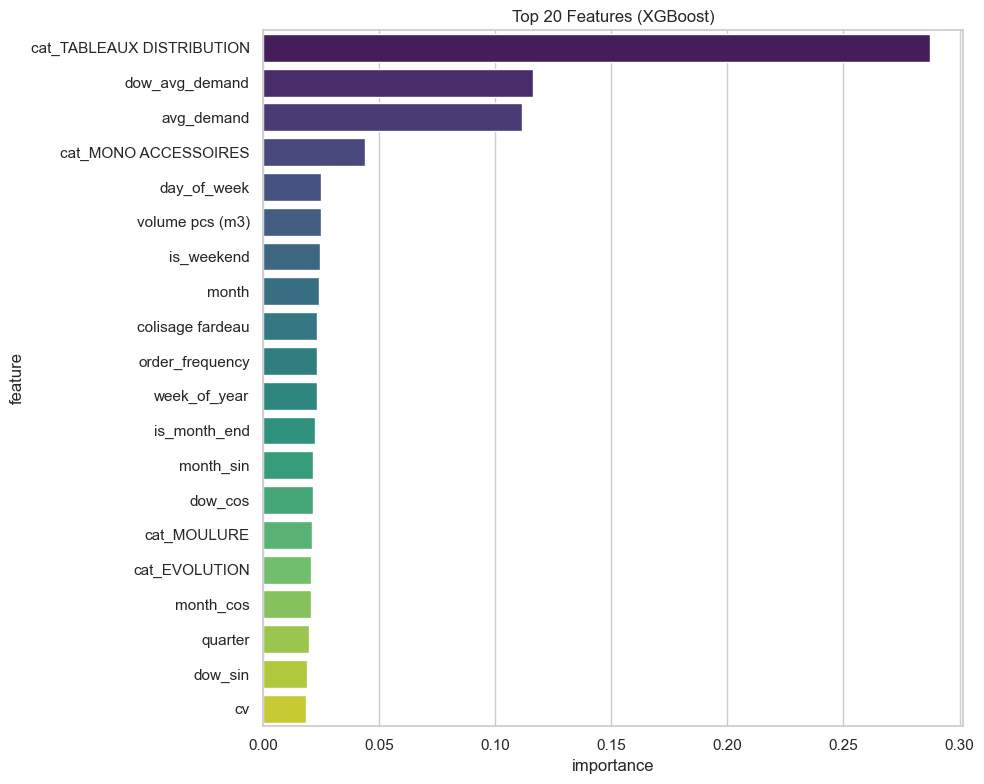

In [23]:
# Feature Importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Features (XGBoost)')
plt.tight_layout()
plt.show()

In [24]:
# Save Model & Features
output_dir = "../../data/models"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

model.save_model(os.path.join(output_dir, "xgboost_model.json"))

with open(os.path.join(output_dir, "feature_columns.pkl"), 'wb') as f:
    pickle.dump(feature_cols, f)

print("✓ Model and feature list saved.")

✓ Model and feature list saved.
